# Confidence-band root finder (`find_confidence_band`)

Example: instead of a uniform grid, locate the band edges directly by bracketing + geometric bisection.
Bracket the outer reach with the widest level (2σ); the narrower 1σ / 90% / 2σ edges nest inside that interval.

- `num_pseudo_data`: pseudo-data sample size during bracketing (can be coarse)
- `n_pseudo_edge`: pseudo-data sample size for the edge bisection (larger suppresses cutoff noise)
- `seed`: fixed value makes every evaluation reproducible and stops the bisection from jittering


Optimization Complete.
Minimum chi-squared: 8.406318406002375e-09
Plot saved as scenario_bkg_flat/flux_comparison_bkg_flat.pdf


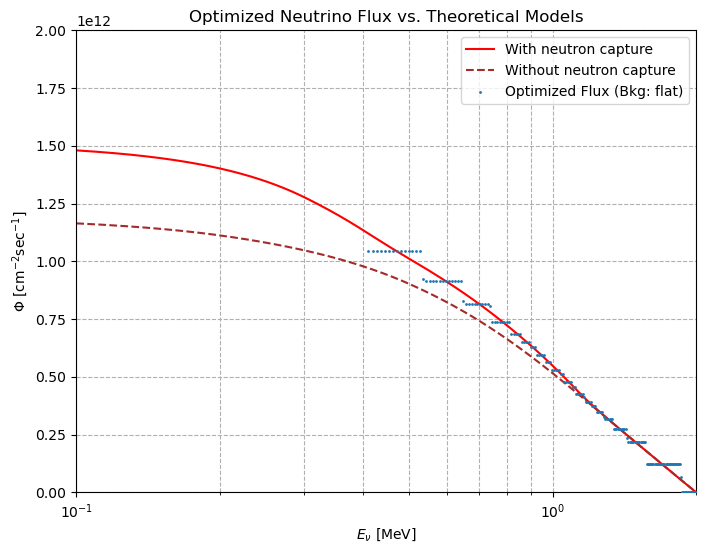

In [8]:
from neutrino_analysis_band import NeutrinoAnalysis

a = NeutrinoAnalysis(background_scenario='flat', intervals='180',
                     GeV=0.32e16, solver='osqp')
a.optimize(a.data_vector)   # Compute the best fit first (populates self.result)
result_flat = a.optimize(a.data_vector)
print("\nOptimization Complete.")
print(f"Minimum chi-squared: {result_flat.fun / a.c}")
# 3. Plot the primary result: the optimized flux vs. theory.
a.plot_flux_comparison(save = True)

In [5]:
# Locate the 1σ / 90% / 2σ edges for one parameter (index=1) in a single call
band = a.find_confidence_band(
    fixed_index=0,
    levels=(0.678, 0.90, 0.954),
    num_pseudo_data=20,    # For bracketing (coarse)
    n_pseudo_edge=200,     # For edge refinement (larger → more stable, slower)
    step=1.5,              # Bracket expansion factor
    rel_tol=0.03,          # Relative tolerance of the edge
    seed=42,
    n_jobs=1,
    verbose=True,
)
band

[band idx=0] v0=1.0446e+12 (phys), bracketing with step=1.5
  upper bracket: 2.6773e+13
  lower bracket: 6.9642e+11
  level 0.678: [9.0880e+11, 1.1750e+13] (phys)
  level 0.900: [8.4227e+11, 2.1046e+13] (phys)
  level 0.954: [8.2119e+11, 2.2709e+13] (phys)


{'index': 0,
 'best_fit_raw': 8830197.814725753,
 'best_fit_physical': 1044634160795.644,
 'levels': (0.678, 0.9, 0.954),
 'band_raw': {0.678: (np.float64(7681993.303959862),
   np.float64(99323038.49982691)),
  0.9: (np.float64(7119619.980682497), np.float64(177902143.96348733)),
  0.954: (np.float64(6941464.541175544), np.float64(191954497.90799153))},
 'band_physical': {0.678: (np.float64(908798737774.2684),
   np.float64(11750160205687.598)),
  0.9: (np.float64(842268587834.0258), np.float64(21046262016137.555)),
  0.954: (np.float64(821192360330.927), np.float64(22708690115487.72))},
 'n_evaluations': 28}

In [6]:
# Put the physical-unit lower/upper edges into a table
import pandas as pd
rows = []
for lv, (lo, hi) in band['band_physical'].items():
    rows.append({'level': lv, 'lower': lo, 'upper': hi})
band_df = pd.DataFrame(rows)
print('best fit (phys) =', band['best_fit_physical'])
print('evaluations     =', band['n_evaluations'])
band_df

best fit (phys) = 1044634160795.644
evaluations     = 28


,level,lower,upper
0,0.678,9.087987e+11,1.175016e+13
1,0.900,8.422686e+11,2.104626e+13
2,0.954,8.211924e+11,2.270869e+13


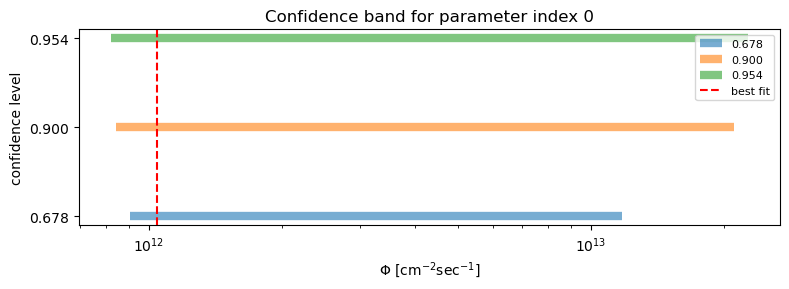

In [7]:
# Visualize the band (horizontal bars centred on the best fit, one per level)
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 3))
colors = {0.678: 'C0', 0.90: 'C1', 0.954: 'C2'}
for i, lv in enumerate(band['levels']):
    lo, hi = band['band_physical'][lv]
    ax.hlines(i, lo, hi, color=colors.get(lv, 'k'), lw=6, alpha=0.6,
              label=f'{lv:.3f}')
ax.axvline(band['best_fit_physical'], color='red', ls='--', label='best fit')
ax.set_yticks(range(len(band['levels'])))
ax.set_yticklabels([f'{lv:.3f}' for lv in band['levels']])
ax.set_xscale('log')
ax.set_xlabel(r'$\Phi$ [cm$^{-2}$sec$^{-1}$]')
ax.set_ylabel('confidence level')
ax.set_title(f"Confidence band for parameter index {band['index']}")
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## Convergence check (optional)

The edge values depend on `n_pseudo_edge` (Monte-Carlo noise in the cutoff).
Increase the value to check whether the edges stabilise.

In [ ]:
for npe in (100, 300):
    b = a.find_confidence_band(1, num_pseudo_data=20, n_pseudo_edge=npe,
                               seed=42, verbose=False)
    lo90, hi90 = b['band_physical'][0.90]
    print(f'n_pseudo_edge={npe:4d}  90% band = [{lo90:.4e}, {hi90:.4e}]  evals={b["n_evaluations"]}')

## Save bands for several indices and overlay them

1. Run `find_and_save_band` per index and save one JSON file per index under `bands/`.
2. Load the saved files with `plot_flux_with_bands` and overlay each index's band as an error bar on top of the `optimize` flux scatter.

`save_band` / `load_band` use a human-readable JSON format. The band centre is the saved `self.result.x[index]`, so it lines up exactly with the scatter from the same `optimize` result.

In [2]:
# Build bands for several indices and save one file per index
# Destination: ./bands/band_bkg<scenario>_idx<NNN>.json
indices = [0, 5, 10, 20, 40]     # Indices to run

for idx in indices:
    print(f'=== index {idx} ===')
    a.find_and_save_band(
        idx,
        outdir='scenario_bkg_flat/bands',
        levels=(0.678, 0.90, 0.954),
        num_pseudo_data=20,
        n_pseudo_edge=200,
        step=1.5,
        rel_tol=0.03,
        seed=42,
        n_jobs=-1,
        verbose=True,
    )

=== index 0 ===
[band idx=0] v0=1.0446e+12 (phys), bracketing with step=1.5
  upper bracket: 2.6773e+13
  lower bracket: 6.9642e+11
  level 0.678: [9.0880e+11, 1.1750e+13] (phys)
  level 0.900: [8.4227e+11, 2.1046e+13] (phys)
  level 0.954: [8.2119e+11, 2.2709e+13] (phys)
Band saved as scenario_bkg_flat/bands/band_bkgflat_idx000.json
=== index 5 ===
[band idx=5] v0=1.3702e+12 (phys), bracketing with step=1.5
  upper bracket: 3.0830e+12
  lower bracket: 6.0898e+11
  level 0.678: [8.1509e+11, 1.8340e+12] (phys)
  level 0.900: [7.7481e+11, 2.4235e+12] (phys)
  level 0.954: [7.5542e+11, 2.6150e+12] (phys)
Band saved as scenario_bkg_flat/bands/band_bkgflat_idx005.json
=== index 10 ===
[band idx=10] v0=1.3520e+12 (phys), bracketing with step=1.5
  upper bracket: 2.0280e+12
  lower bracket: 6.0089e+11
  level 0.678: [8.0426e+11, 1.3694e+12] (phys)
  level 0.900: [7.6451e+11, 1.5543e+12] (phys)
  level 0.954: [7.4538e+11, 1.5942e+12] (phys)
Band saved as scenario_bkg_flat/bands/band_bkgflat_id

Plot saved as scenario_bkg_flat/flux_with_bands_bkg_flat.pdf


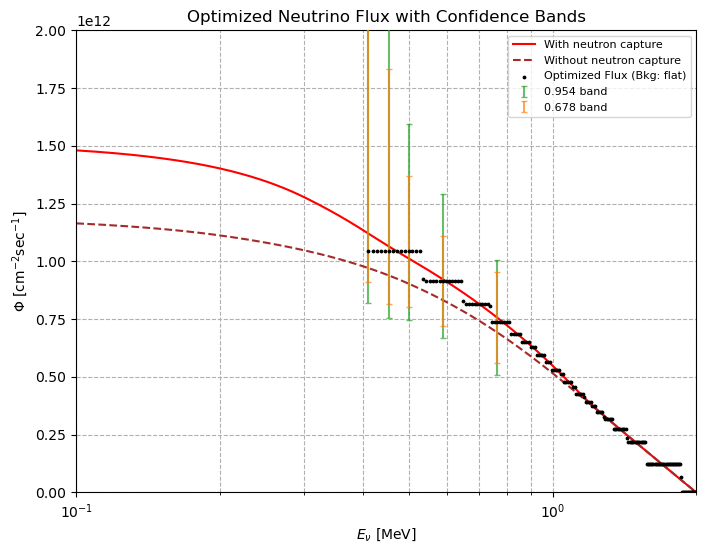

In [10]:
# Load the saved bands and overlay them on the optimize result
# band_files can be a glob pattern or an explicit list
a.plot_flux_with_bands(
    f'scenario_bkg_flat/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # Levels to plot (omit to show all saved levels)
    save=True,
    ylim=(0, 3e13),                # So the high-flux tail is visible
)
import matplotlib.pyplot as plt
#plt.yscale('log')
plt.ylim(0, 2e12)
plt.show()